# FigAppTruncatedSpectraComparison — truncation sensitivity of the emergent spectra

Appendix figure: how much the emergent spectrum depends on whether the unconverged
outer wind is retained (full domain) or made transparent (`*_trunc_speconly`), for the
two Mdot = 15 Msun/yr production runs. **Panel (a)**: full-band continuum spectra,
truncated (solid) vs full-domain (dashed). **Panel (b)**: the Halpha profile, same
comparison. Each family pair is normalized to its full-domain spectrum (continuum at
6000 A in panel a; line peak in panel b) and the marginally-unbound pair is offset
upward (x100) so the pairs do not overlap. Redward of the Balmer edge the treatments
agree to ~2x or better; blueward the difference is orders of magnitude (the total-vs-
modest break dichotomy) — that region is not a robust prediction of these models.


In [18]:
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter
from matplotlib.lines import Line2D

# ================= config: edit here to point at your data / output =================
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")
# (parent full-domain dir, truncated spec-only dir) per family, Mdot = 15
PAIRS = {
    "mu_m15":  ("repro/mu_m15",       "repro/mu_m15_trunc_speconly"),
    "ptf_m15": ("repro/ptf_m15_n300", "repro/ptf_m15_n300_trunc_speconly"),
}
MB_COLOR, PT_COLOR = 'tab:orange', 'tab:blue'
OBS_COL    = 'A45P0.50'
C_KMS      = 299792.458
C_AA_S     = 2.99792458e18
HA_LAM0    = 6562.8
SMOOTH_KMS = 1000.0        # continuum boxcar (panel a)
XTICKS     = [0.1, 0.2, 0.3, 0.5, 1.0]   # same as Fig_LRD_gallery
SMOOTH_HA  = 25.0          # light Halpha smoothing (panel b)
OFFSET_MU  = 10000.0         # vertical offset of the mu pair (arbitrary normalization)
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})
# ====================================================================================

def _spec_path(rel):
    "Root-aware full-band log_spec ('outflow' for standard runs, 'spec' for trunc reruns)."
    base = os.path.join(DATA_ROOT, rel)
    for root in ('outflow', 'spec'):
        p = f'{base}/{root}.log_spec'
        if os.path.exists(p):
            return p
    raise FileNotFoundError(base)

def _ha_path(rel):
    "Prefer the narrow-band halpha_hires restart for the line, else the full-band file."
    hi = os.path.join(DATA_ROOT, rel, 'halpha_hires', 'outflow.log_spec')
    return hi if os.path.exists(hi) else _spec_path(rel)

def continuum(rel):
    "lambda [um], boxcar-smoothed F_lambda (Freq-based wavelengths)."
    s   = pd.read_csv(_spec_path(rel), sep=r'\s+', comment='#')
    nu  = s['Freq.'].to_numpy()
    lam = C_AA_S / nu / 1e4
    dv  = C_KMS * np.median(np.abs(np.diff(np.log(nu))))
    fl  = uniform_filter1d(s[OBS_COL].to_numpy(), size=max(1, round(SMOOTH_KMS / dv)))
    o   = np.argsort(lam)
    return lam[o], fl[o]

def halpha(rel):
    "velocity [km/s] vs F_lambda around Halpha (Freq-based; Lambda column is rounded)."
    s   = pd.read_csv(_ha_path(rel), sep=r'\s+', comment='#')
    nu  = s['Freq.'].to_numpy()
    lam = C_AA_S / nu
    v   = C_KMS * (lam - HA_LAM0) / HA_LAM0
    fl  = s[OBS_COL].to_numpy()
    keep = (v > -3000) & (v < 3000)
    v, fl = v[keep], fl[keep]
    o = np.argsort(v); v, fl = v[o], fl[o]
    dv = np.median(np.diff(v))
    if dv > 0 and SMOOTH_HA > 0:
        fl = uniform_filter1d(fl, size=max(1, round(SMOOTH_HA / dv)))
    return v, fl


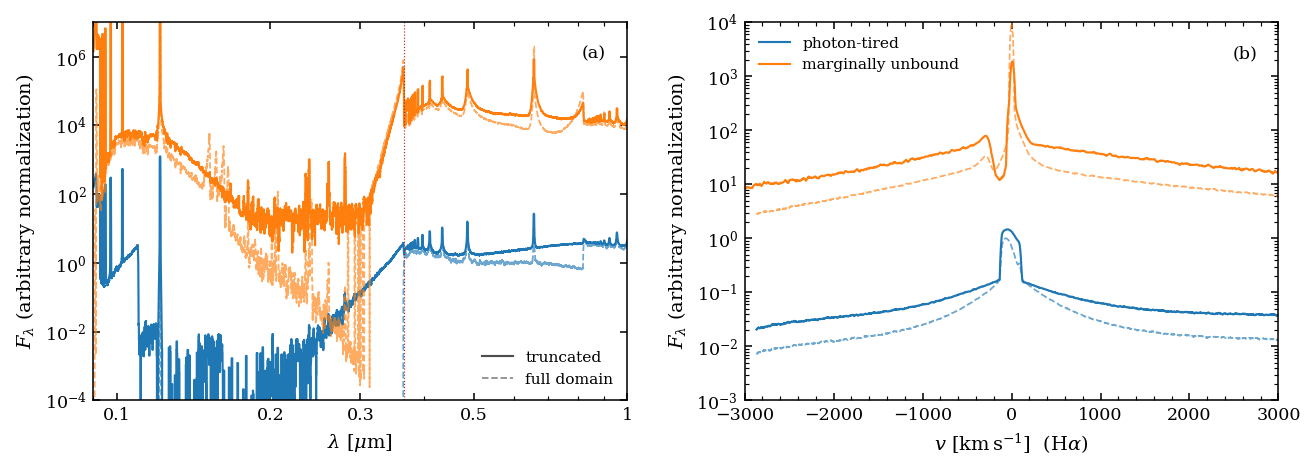

In [19]:
# ===== two panels: (a) continuum trunc vs full-domain, (b) Halpha trunc vs full-domain =====
fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.2, 3.6))
fig.subplots_adjust(left=0.07, right=0.99, top=0.9, bottom=0.15, wspace=0.22)

for key, color, off in [('ptf_m15', PT_COLOR, 1.0), ('mu_m15', MB_COLOR, OFFSET_MU)]:
    parent_rel, trunc_rel = PAIRS[key]
    # --- panel (a): continuum, pair normalized to the full-domain continuum at 6000 A
    lp, fp = continuum(parent_rel)
    lt, ft = continuum(trunc_rel)
    norm = np.median(fp[(lp > 0.58) & (lp < 0.62)])
    axA.plot(lp, off * fp / norm, color=color, lw=0.9, ls='--', alpha=0.65)
    axA.plot(lt, off * ft / norm, color=color, lw=1.1)
    # --- panel (b): Halpha, pair normalized to the full-domain line peak
    vp, hp = halpha(parent_rel)
    vt, ht = halpha(trunc_rel)
    norm = hp.max()
    axB.plot(vp, off * hp / norm, color=color, lw=0.9, ls='--', alpha=0.65)
    axB.plot(vt, off * ht / norm, color=color, lw=1.1)

axA.axvline(0.3646, color='firebrick', lw=0.6, ls=':')
axA.set(xscale='log', yscale='log', xlim=(0.09, 1.0), ylim=(1e-4, 1e7),
        xlabel=r'$\lambda\ [\mu\mathrm{m}]$',
        ylabel=r'$F_\lambda$ (arbitrary normalization)')
axA.text(0.96, 0.94, '(a)', transform=axA.transAxes, va='top', ha='right')
axB.set(yscale='log', xlim=(-3000, 3000), ylim=(1e-3, 1e4),
        xlabel=r'$v\ [\mathrm{km\,s^{-1}}]\ \ (\mathrm{H}\alpha)$',
        ylabel=r'$F_\lambda$ (arbitrary normalization)')
axB.text(0.96, 0.94, '(b)', transform=axB.transAxes, va='top', ha='right')

axA.xaxis.set_major_locator(FixedLocator(XTICKS))                 # same ticks as Fig_LRD_gallery
axA.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:g}'))
axA.xaxis.set_minor_formatter(NullFormatter())

handles = [Line2D([0], [0], color='0.3', lw=1.1, label='truncated'),
           Line2D([0], [0], color='0.3', lw=0.9, ls='--', alpha=0.65, label='full domain')]
axA.legend(handles=handles, loc='lower right', fontsize=8, frameon=False)
famhandles = [Line2D([0], [0], color=PT_COLOR, lw=1.1, label='photon-tired'),
              Line2D([0], [0], color=MB_COLOR, lw=1.1, label='marginally unbound')]
axB.legend(handles=famhandles, loc='upper left', fontsize=8, frameon=False)

fig.savefig(os.path.join(FIG_DIR, 'FigAppTruncatedSpectraComparison.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'FigAppTruncatedSpectraComparison.png'), dpi=300)
plt.show()
